# House Prices - Lasso Feature Selection

This notebook extends the previous Ridge-based stage of the project.

Goal:
- keep the same polynomial feature representation used by the best Ridge model
- replace Ridge with Lasso regularization
- tune `alpha` with 5-fold cross-validation
- generate a new Kaggle submission
- analyze sparsity and implicit feature selection

This allows a controlled comparison between L2 and L1 regularization on the same tabular regression problem.

## 1. Load the data and define the target

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

X = train_df.drop("SalePrice", axis=1)
y_log = np.log(train_df["SalePrice"])
X_test = test_df.copy()

print("X shape:", X.shape)
print("y_log shape:", y_log.shape)
print("X_test shape:", X_test.shape)

X shape: (1460, 80)
y_log shape: (1460,)
X_test shape: (1459, 80)


## 2. Define the feature groups

In [10]:
numeric_features = X.select_dtypes(include=["number"]).columns.drop("Id")
categorical_features = X.select_dtypes(exclude=["number"]).columns

poly_features = ["GrLivArea", "OverallQual", "TotalBsmtSF", "GarageArea"]

remaining_numeric_features = [
    col for col in numeric_features if col not in poly_features
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Polynomial features:", poly_features)
print("Remaining numeric features:", len(remaining_numeric_features))

Numeric features: 36
Categorical features: 43
Polynomial features: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea']
Remaining numeric features: 32


## 3. Build the preprocessing pipeline

In [11]:
poly_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

remaining_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_poly = ColumnTransformer(transformers=[
    ("poly_num", poly_numeric_transformer, poly_features),
    ("num", remaining_numeric_transformer, remaining_numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor ready.")

Preprocessor ready.


## 4. Reproduce the best Polynomial Ridge benchmark

Before testing Lasso, we reproduce the best Polynomial Ridge model from the previous notebook.

This gives us a stable benchmark:
- same preprocessing
- same selected polynomial features
- same cross-validation setup

In this way, the only real change is the regularization type: L2 vs L1.

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_benchmark_model = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", Ridge(alpha=2.0))
])

ridge_scores = cross_val_score(
    ridge_benchmark_model,
    X,
    y_log,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_rmse = -ridge_scores

print("Ridge fold RMSE:", ridge_rmse)
print("Ridge mean CV RMSE:", ridge_rmse.mean())
print("Ridge std CV RMSE:", ridge_rmse.std())

Ridge fold RMSE: [0.12371615 0.11841978 0.15102688 0.12072384 0.10790964]
Ridge mean CV RMSE: 0.12435925780325499
Ridge std CV RMSE: 0.014357294665117346


## 5. Tune Lasso with 5-fold cross-validation

In [13]:
lasso_alphas = [0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]

lasso_results = []

for alpha in lasso_alphas:
    lasso_model = Pipeline(steps=[
        ("preprocessor", preprocessor_poly),
        ("model", Lasso(alpha=alpha, max_iter=20000))
    ])

    scores = cross_val_score(
        lasso_model,
        X,
        y_log,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    rmse_scores = -scores

    lasso_results.append({
        "alpha": alpha,
        "mean_cv_rmse": rmse_scores.mean(),
        "std_cv_rmse": rmse_scores.std()
    })

lasso_results_df = pd.DataFrame(lasso_results).sort_values("mean_cv_rmse")
lasso_results_df

,alpha,mean_cv_rmse,std_cv_rmse
1,0.0003,0.123856,0.019443
0,0.0001,0.125599,0.015956
2,0.0010,0.134767,0.037419
3,0.0030,0.147616,0.048140
4,0.0100,0.158120,0.045342
5,0.0300,0.178191,0.036849


## 6. Compare the best Lasso result against Ridge

In [14]:
best_lasso_row = lasso_results_df.iloc[0]

print("Best Lasso alpha:", best_lasso_row["alpha"])
print("Best Lasso mean CV RMSE:", best_lasso_row["mean_cv_rmse"])
print("Best Lasso std CV RMSE:", best_lasso_row["std_cv_rmse"])
print()
print("Current Ridge benchmark mean CV RMSE:", ridge_rmse.mean())
print("Difference (Lasso - Ridge):", best_lasso_row["mean_cv_rmse"] - ridge_rmse.mean())

Best Lasso alpha: 0.0003
Best Lasso mean CV RMSE: 0.12385617304987953
Best Lasso std CV RMSE: 0.019443236201871838

Current Ridge benchmark mean CV RMSE: 0.12435925780325499
Difference (Lasso - Ridge): -0.0005030847533754601


## 7. Refit the best Lasso model on the full training set

In [15]:
best_lasso_alpha = float(best_lasso_row["alpha"])

best_lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor_poly),
    ("model", Lasso(alpha=best_lasso_alpha, max_iter=20000))
])

best_lasso_model.fit(X, y_log)

print("Best Lasso final model fitted on full training set.")
print("alpha =", best_lasso_alpha)

Best Lasso final model fitted on full training set.
alpha = 0.0003


## 8. Generate the Kaggle submission

In [16]:
test_pred_log_lasso = best_lasso_model.predict(X_test)
test_pred_lasso = np.exp(test_pred_log_lasso)

print("Number of predictions:", len(test_pred_lasso))
print("First 10 predicted prices:")
print(test_pred_lasso[:10])

Number of predictions: 1459
First 10 predicted prices:
[119013.89281324 154895.73425946 179990.59830456 199290.9961716
 196241.108232   171750.80427672 184185.75420867 160288.13835308
 196481.74990523 119844.91400985]


In [17]:
submission_lasso = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_pred_lasso
})

print(submission_lasso.shape)
submission_lasso.head()

(1459, 2)


,Id,SalePrice
0,1461,119013.892813
1,1462,154895.734259
2,1463,179990.598305
3,1464,199290.996172
4,1465,196241.108232


In [18]:
submission_lasso_path = "../submissions/submission_lasso_alpha_0_0003_cv.csv"

submission_lasso.to_csv(submission_lasso_path, index=False)

print("Submission saved to:", submission_lasso_path)

Submission saved to: ../submissions/submission_lasso_alpha_0_0003_cv.csv


## 9. Inspect the learned coefficients

In [19]:
lasso_preprocessor = best_lasso_model.named_steps["preprocessor"]
lasso_regressor = best_lasso_model.named_steps["model"]

feature_names = lasso_preprocessor.get_feature_names_out()
coefficients = lasso_regressor.coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "abs_coefficient": np.abs(coefficients)
})

print("Number of transformed features:", len(coef_df))
coef_df.head()

Number of transformed features: 297


,feature,coefficient,abs_coefficient
0,poly_num__GrLivArea,0.229503,0.229503
1,poly_num__OverallQual,0.012362,0.012362
2,poly_num__TotalBsmtSF,0.083244,0.083244
3,poly_num__GarageArea,0.014996,0.014996
4,poly_num__GrLivArea^2,-0.033027,0.033027


## 10. Measure sparsity

A key property of Lasso is that it can set some coefficients exactly to zero.

This means that, unlike Ridge, Lasso can perform implicit feature selection while fitting the regression model.

In [20]:
n_total = len(coef_df)
n_zero = (coef_df["coefficient"] == 0).sum()
n_nonzero = (coef_df["coefficient"] != 0).sum()

print("Total transformed features:", n_total)
print("Zero coefficients:", n_zero)
print("Non-zero coefficients:", n_nonzero)
print("Sparsity (% zero):", round(n_zero / n_total * 100, 2))

Total transformed features: 297
Zero coefficients: 154
Non-zero coefficients: 143
Sparsity (% zero): 51.85


## 11. Identify the most influential selected features

In [21]:
coef_df_nonzero = coef_df[coef_df["coefficient"] != 0].copy()

top_features = coef_df_nonzero.sort_values("abs_coefficient", ascending=False)

top_features[["feature", "coefficient", "abs_coefficient"]].head(20)

,feature,coefficient,abs_coefficient
46,cat__MSZoning_C (all),-0.346025,0.346025
111,cat__Condition2_PosN,-0.310602,0.310602
0,poly_num__GrLivArea,0.229503,0.229503
6,poly_num__GrLivArea TotalBsmtSF,-0.138577,0.138577
79,cat__Neighborhood_Crawfor,0.117789,0.117789
238,cat__Functional_Maj2,-0.097279,0.097279
9,poly_num__OverallQual TotalBsmtSF,0.095909,0.095909
95,cat__Neighborhood_StoneBr,0.092967,0.092967
2,poly_num__TotalBsmtSF,0.083244,0.083244
243,cat__Functional_Typ,0.074350,0.074350


## 12. Separate positive and negative effects

In [22]:
top_positive = coef_df_nonzero.sort_values("coefficient", ascending=False)
top_negative = coef_df_nonzero.sort_values("coefficient", ascending=True)

print("Top positive coefficients:")
display(top_positive[["feature", "coefficient"]].head(15))

print("Top negative coefficients:")
display(top_negative[["feature", "coefficient"]].head(15))

Top positive coefficients:


,feature,coefficient
0,poly_num__GrLivArea,0.229503
79,cat__Neighborhood_Crawfor,0.117789
9,poly_num__OverallQual TotalBsmtSF,0.095909
95,cat__Neighborhood_StoneBr,0.092967
2,poly_num__TotalBsmtSF,0.083244
243,cat__Functional_Typ,0.074350
141,cat__RoofMatl_WdShngl,0.074334
145,cat__Exterior1st_BrkFace,0.070436
233,cat__KitchenQual_Ex,0.061902
88,cat__Neighborhood_NoRidge,0.061638


Top negative coefficients:


,feature,coefficient
46,cat__MSZoning_C (all),-0.346025
111,cat__Condition2_PosN,-0.310602
6,poly_num__GrLivArea TotalBsmtSF,-0.138577
238,cat__Functional_Maj2,-0.097279
218,cat__Heating_Grav,-0.072005
83,cat__Neighborhood_MeadowV,-0.067113
291,cat__SaleCondition_Abnorml,-0.053377
50,cat__MSZoning_RM,-0.049693
226,cat__CentralAir_N,-0.043865
72,cat__LandSlope_Sev,-0.043617


## 13. Visualize the top selected coefficients

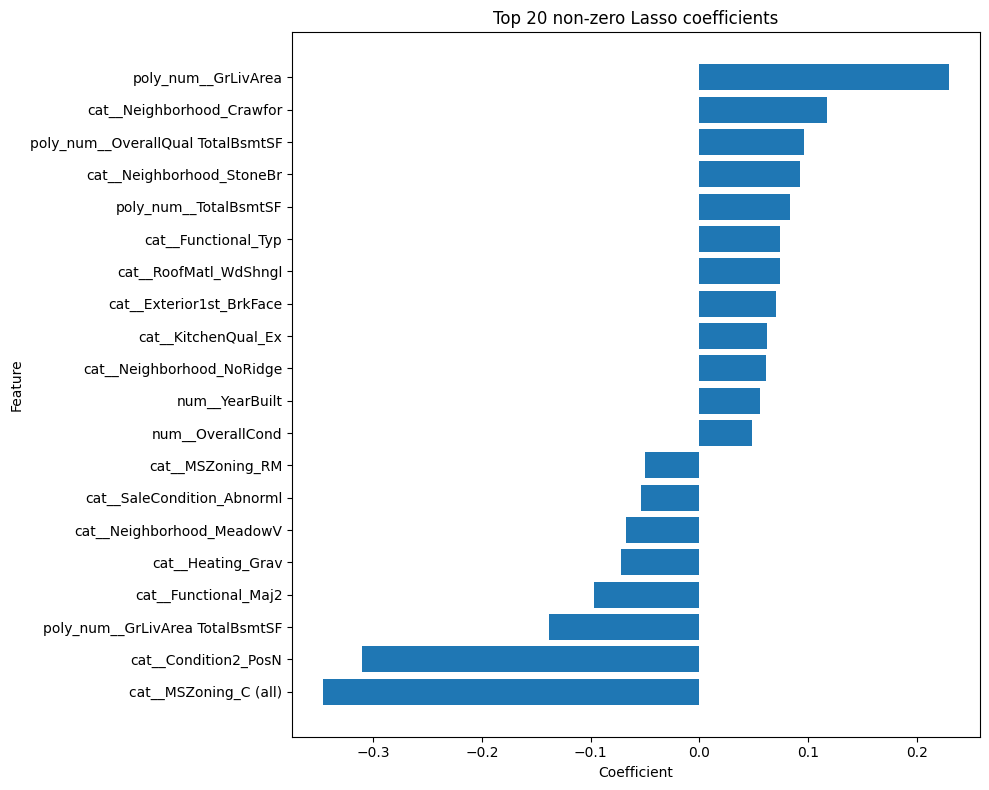

In [23]:
top20 = top_features.head(20).sort_values("coefficient")

plt.figure(figsize=(10, 8))
plt.barh(top20["feature"], top20["coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top 20 non-zero Lasso coefficients")
plt.tight_layout()
plt.show()

## 14. Conclusions

This notebook tested Lasso regression on top of the same polynomial feature representation previously used by the best Ridge model.

Main results:
- Best alpha selected by 5-fold cross-validation: `0.0003`
- Mean CV RMSE: `0.123856`
- Kaggle public score: `0.12354`

Feature selection effect:
- Total transformed features: `297`
- Non-zero coefficients: `143`
- Zero coefficients: `154`
- Sparsity: `51.85%`

Lasso improved over the previous Polynomial Ridge benchmark both in cross-validation and on the Kaggle public leaderboard.

This confirms the expected behavior of L1 regularization:
- coefficient shrinkage
- implicit feature selection
- potentially better generalization in high-dimensional tabular data

The next natural step is to test ElasticNet, combining L1 and L2 regularization.